In [1]:
# Core imports
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
from pathlib import Path

# Keras imports
from tensorflow import keras
from keras import layers, Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (10, 6),
    'axes.grid': False
})

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Download and extract dataset (only if not already present)
if not Path('New_landmark_images').exists():
    !gdown 11LQILlalZGi_skLIipnpTyh-At77B_j6 -q
    !unzip -qq -o New_landmark_images.zip
    print("Dataset downloaded and extracted!")
else:
    print("Dataset already exists, skipping download.")

Dataset already exists, skipping download.


In [3]:
# Configuration
CONFIG = {
    'data_dir': Path('New_landmark_images'),
    'img_size': (224, 224),
    'batch_size': 512,
    'epochs_scratch': 15,
    'epochs_transfer': 10,
    'num_classes': 10
}

In [4]:
def load_dataset(data_dir, img_size, batch_size, seed=SEED):
    """
    Load train, validation, and test datasets using tf.keras.utils.image_dataset_from_directory.

    Returns normalized datasets with optimized data pipeline.
    """
# Load raw datasets
    train_ds = keras.utils.image_dataset_from_directory(
        data_dir / 'train',
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True,
        seed=seed
    )

    val_ds = keras.utils.image_dataset_from_directory(
        data_dir / 'validation',
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False
    )

    test_ds = keras.utils.image_dataset_from_directory(
        data_dir / 'test',
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False
    )

    class_names = train_ds.class_names


    normalization = layers.Rescaling(1.0 / 255)

    train_ds = train_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(lambda x, y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [5]:
# Load datasets
train_ds, val_ds, test_ds, class_names = load_dataset(
    CONFIG['data_dir'],
    CONFIG['img_size'],
    CONFIG['batch_size']
)

print(f"Classes ({len(class_names)}): {class_names}")

Found 737 files belonging to 10 classes.
Found 155 files belonging to 10 classes.
Found 43 files belonging to 10 classes.


2026-08-01 22:14:25.940039: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-08-01 22:14:25.940104: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-08-01 22:14:25.940111: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
I0000 00:00:1785602665.940146 14115548 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785602665.940204 14115548 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Classes (10): ['01.Niagara_Falls', '02.Golden_Gate_Bridge', '03.Kantanagar_Temple', '04.Eiffel_Tower', '05.Washington_Monument', '06.Hanging_Temple', '07.Forth_Bridge', '08.Gateway_of_India', '09.Machu_Picchu', '10.Great_Wall_of_China']


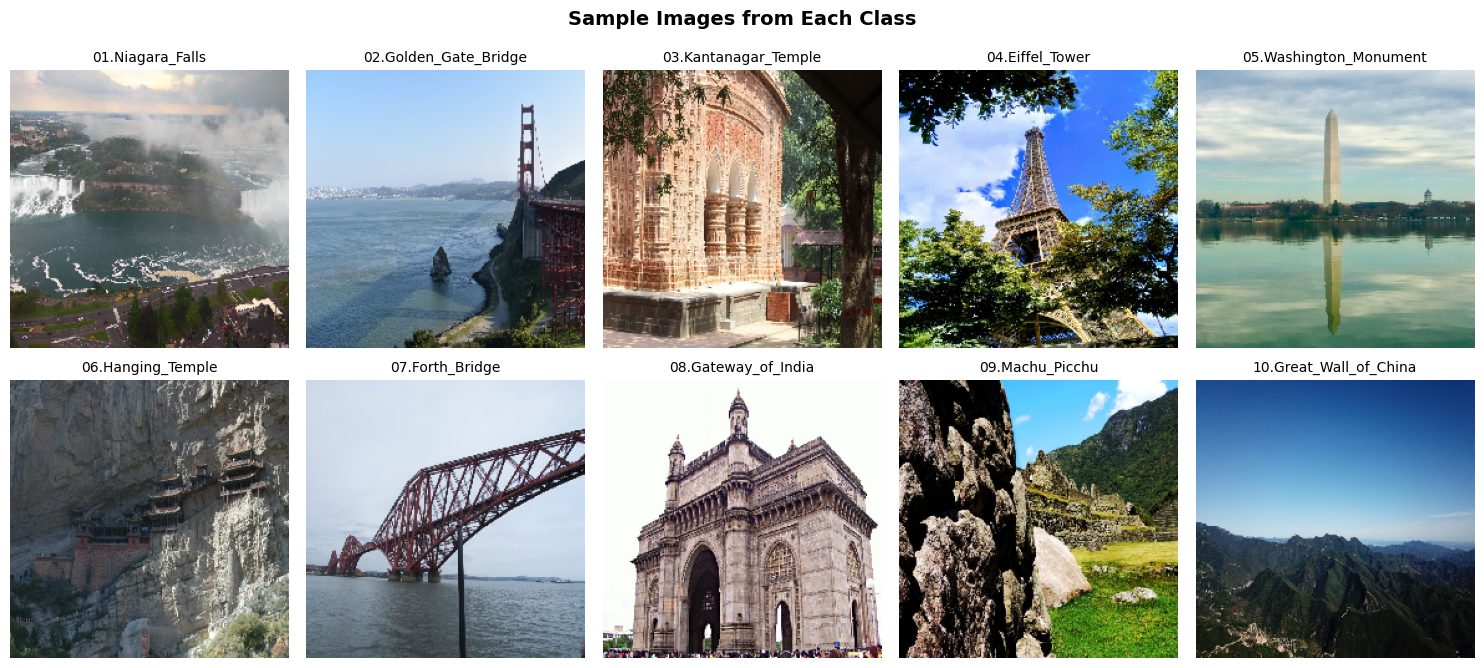

In [6]:
def visualize_samples(data_dir, class_names, samples_per_class=1):
    """Display random sample images from each class."""
    n_classes = len(class_names)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten()

    for idx, class_name in enumerate(class_names):
        class_path = Path(data_dir) / 'train' / class_name
        image_files = list(class_path.glob('*'))

        if image_files:
            sample_path = random.choice(image_files)
            img = keras.utils.load_img(sample_path, target_size=CONFIG['img_size'])

            axes[idx].imshow(img)
            axes[idx].set_title(class_name, fontsize=10)
            axes[idx].axis('off')

    plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(CONFIG['data_dir'], class_names)

# Part 1

In [7]:
def build_custom_cnn(input_shape, num_classes):

    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),


        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),


        # Block 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CustomCNN')

    return model



In [8]:
# Build the model
input_shape = (*CONFIG['img_size'], 3)  # (224, 224, 3)
custom_cnn = build_custom_cnn(input_shape, CONFIG['num_classes'])

# Display architecture
custom_cnn.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 325,418 (1.24 MB)

 Trainable params: 324,010 (1.24 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [9]:
# Compile the model
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("Training Custom CNN from Scratch...")
print("="*50)

history_scratch = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs_scratch']

)

Training Custom CNN from Scratch...
Epoch 1/15


2026-08-01 22:14:30.610042: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 9s/step - accuracy: 0.1384 - loss: 3.0197 - val_accuracy: 0.0968 - val_loss: 2.3020
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.2836 - loss: 2.1286 - val_accuracy: 0.0968 - val_loss: 2.3023
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3379 - loss: 1.8684 - val_accuracy: 0.0968 - val_loss: 2.3031
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.3948 - loss: 1.7527 - val_accuracy: 0.1032 - val_loss: 2.3050
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4464 - loss: 1.6373 - val_accuracy: 0.0968 - val_loss: 2.3071
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4654 - loss: 1.5457 - val_accuracy: 0.0774 - val_loss: 2.3104
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4708 - loss: 1.5115 - val_accuracy: 0.0968 - val_loss: 2.3135
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5007 - loss: 1.4488 - val_accuracy: 0.0968 - val_loss: 2.3191
Epoch 9/15
2/2 ━━━━━━━━━━━

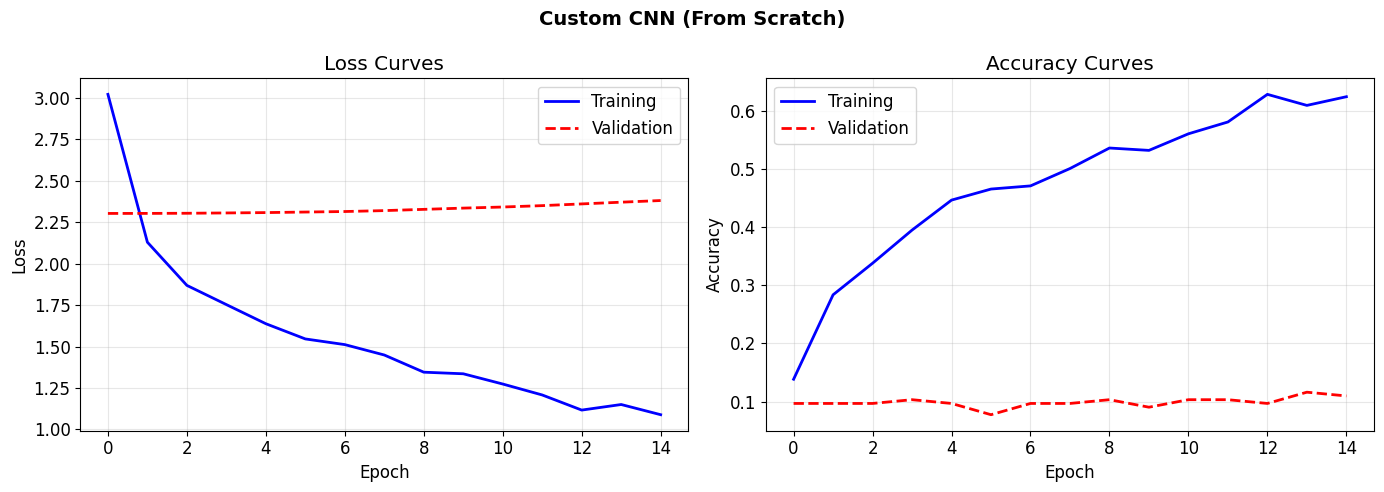

In [11]:
def plot_training_history(history, title="Training History"):
    """
    Plot training and validation loss/accuracy curves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(history.history['loss'], 'b-', linewidth=2, label='Training')
    axes[0].plot(history.history['val_loss'], 'r--', linewidth=2, label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history.history['accuracy'], 'b-', linewidth=2, label='Training')
    axes[1].plot(history.history['val_accuracy'], 'r--', linewidth=2, label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history_scratch, "Custom CNN (From Scratch)")

In [12]:
# Evaluate on test set
print("Evaluating Custom CNN on Test Set...")
scratch_loss, scratch_acc = custom_cnn.evaluate(test_ds, verbose=0)
print(f"\n📊 Custom CNN Results:")
print(f"   Test Loss: {scratch_loss:.4f}")
print(f"   Test Accuracy: {scratch_acc:.2%}")

Evaluating Custom CNN on Test Set...

📊 Custom CNN Results:
   Test Loss: 2.3735
   Test Accuracy: 11.63%


# Part 2 - Transfer Learning

In [13]:
def build_transfer_model(input_shape, num_classes):
    
    base_model = keras.applications.VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    base_model.trainable = False


    model = keras.Sequential([
        # Pretrained convolutional base
        base_model,
        
        # Our custom classification head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='VGG16_Transfer')

    return model, base_model




In [14]:
# Build the transfer learning model
transfer_model, base_model = build_transfer_model(input_shape, CONFIG['num_classes'])

# Display architecture
transfer_model.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Let's examine the frozen base model
print(f"Base model layers: {len(base_model.layers)}")
print(f"Base model trainable: {base_model.trainable}")
print(f"\nTrainable parameters in transfer model: {transfer_model.count_params() - base_model.count_params():,}")
print(f"Frozen parameters: {base_model.count_params():,}")

Base model layers: 19
Base model trainable: False

Trainable parameters in transfer model: 133,898
Frozen parameters: 14,714,688


In [16]:
# Compile the model
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.0855 - loss: 2.4124 - val_accuracy: 0.1226 - val_loss: 2.2896
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.1805 - loss: 2.2304 - val_accuracy: 0.2903 - val_loss: 2.2113
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3664 - loss: 2.1413 - val_accuracy: 0.3613 - val_loss: 2.1065
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4301 - loss: 2.0312 - val_accuracy: 0.4065 - val_loss: 1.9852
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4939 - loss: 1.9143 - val_accuracy: 0.4839 - val_loss: 1.8799
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5278 - loss: 1.8145 - val_accuracy: 0.5484 - val_loss: 1.7895
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5604 - loss: 1.7246 - val_accuracy: 0.5742 - val_loss: 1.7036
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6052 - loss: 1.6362 - val_accuracy: 0.6000 - val_loss: 1.6195
Epoch 9/20
2/2 ━

In [17]:

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7666 - loss: 0.9396 - val_accuracy: 0.7935 - val_loss: 0.9211
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7815 - loss: 0.9099 - val_accuracy: 0.8129 - val_loss: 0.8912
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7883 - loss: 0.8822 - val_accuracy: 0.8129 - val_loss: 0.8636
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7924 - loss: 0.8564 - val_accuracy: 0.8129 - val_loss: 0.8385
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7965 - loss: 0.8324 - val_accuracy: 0.8194 - val_loss: 0.8157


In [18]:
# Evaluate on test set
print("Evaluating Transfer Learning Model on Test Set...")
transfer_loss, transfer_acc = transfer_model.evaluate(test_ds, verbose=0)
print(f"\n📊 Transfer Learning Results:")
print(f"   Test Loss: {transfer_loss:.4f}")
print(f"   Test Accuracy: {transfer_acc:.2%}")

Evaluating Transfer Learning Model on Test Set...

📊 Transfer Learning Results:
   Test Loss: 0.8577
   Test Accuracy: 79.07%



Transfer Learning Model Predictions:


2026-08-01 22:22:41.951255: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-08-01 22:22:41.956995: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


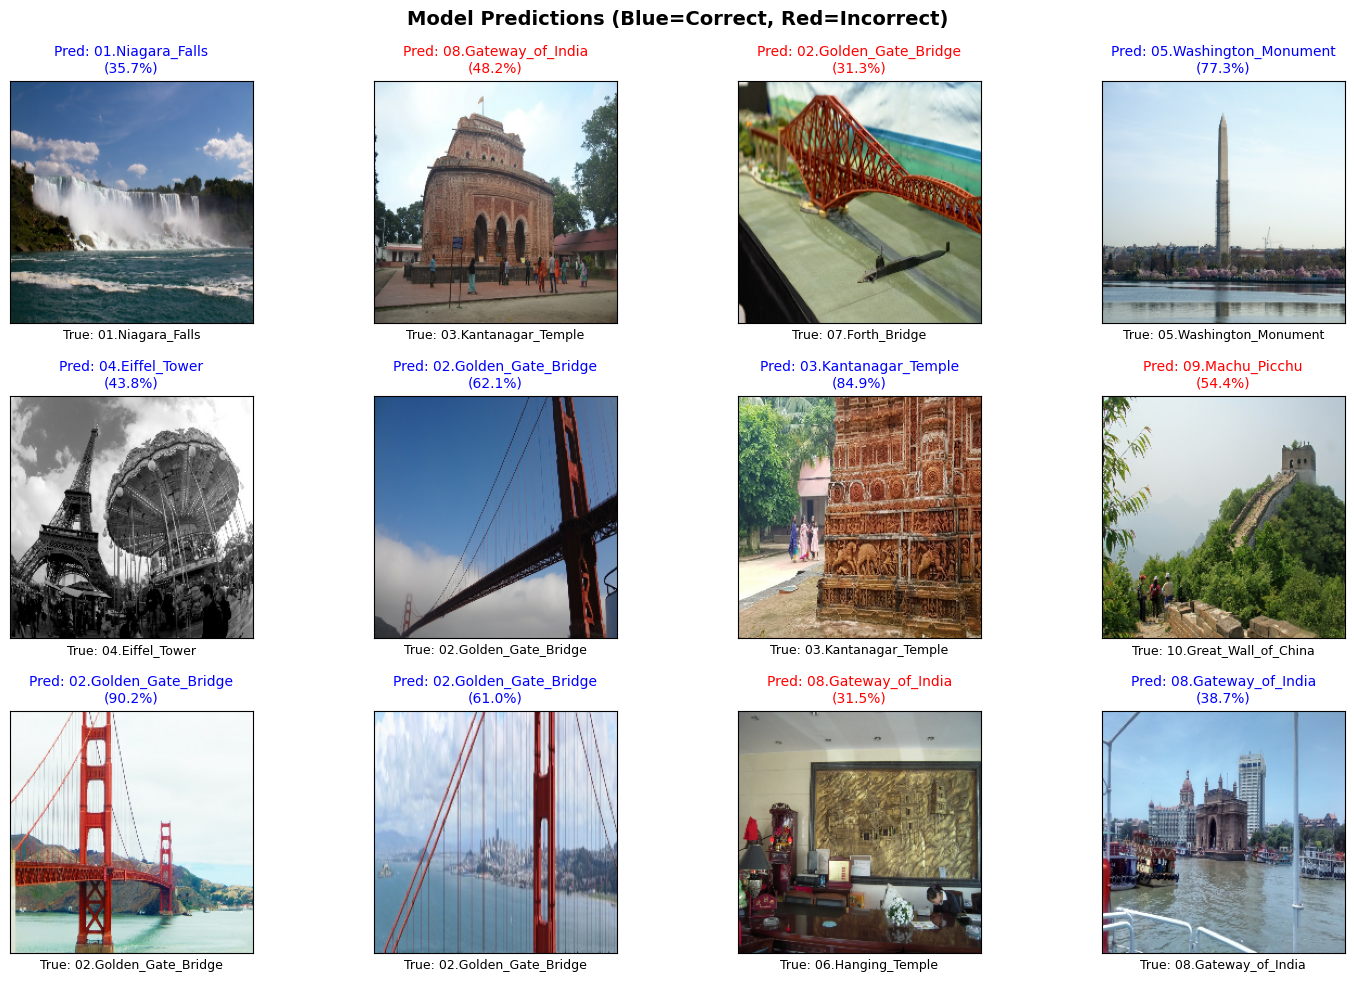

In [19]:
def visualize_predictions(model, test_ds, class_names, num_samples=12):
    """
    Visualize model predictions on test samples.
    Correct predictions shown in blue, incorrect in red.
    """
    # Get all test images and labels
    images = np.concatenate([x for x, y in test_ds], axis=0)
    labels = np.concatenate([y for x, y in test_ds], axis=0)
    
    # Get predictions
    predictions = model.predict(test_ds, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    
    # Randomly sample indices
    indices = random.sample(range(len(images)), min(num_samples, len(images)))
    
    # Plot
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        
        # Display image (already normalized, so scale back for display)
        ax.imshow(images[idx])
        
        true_label = class_names[labels[idx]]
        pred_label = class_names[pred_classes[idx]]
        confidence = predictions[idx][pred_classes[idx]] * 100
        
        # Color based on correctness
        color = 'blue' if labels[idx] == pred_classes[idx] else 'red'
        
        ax.set_title(f'Pred: {pred_label}\n({confidence:.1f}%)', 
                    fontsize=10, color=color)
        ax.set_xlabel(f'True: {true_label}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.suptitle('Model Predictions (Blue=Correct, Red=Incorrect)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nTransfer Learning Model Predictions:")
visualize_predictions(transfer_model, test_ds, class_names)